In [1]:
import random
from dataclasses import dataclass
from typing import List, Dict, Any, Optional
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm import tqdm
import pandas as pd
import torch
import torch.nn.functional as F
import torch
from typing import Dict, Optional

from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments
from datasets import load_dataset
from utils.gsm8k_tokenizer import GSM8KTokenizerProcessor

from utils.prob_mmlu_gen import build_mmlu_probe_dataset, tokenize_probe_dataset, load_processed_dataset

In [2]:
def get_inner_and_cosine(h1, h2):
    h1 = h1.float()
    h2 = h2.float()

    h1_norm = h1 / (h1.norm(dim=1, keepdim=True) + 1e-8)
    h2_norm = h2 / (h2.norm(dim=1, keepdim=True) + 1e-8)

    inner = h1 @ h2.T
    cosine = h1_norm @ h2_norm.T
    return inner, cosine

@torch.no_grad()
def compute_h_vs_w_scores(
    h_u: torch.Tensor,
    h_l: torch.Tensor,
    W: torch.Tensor,
    *,
    use_cosine_alpha: bool = False,
    power_iter_steps: int = 50,
    chunk_size: Optional[int] = None,
    return_wtw: bool = False,
) -> Dict[str, float]:
    """
    Compare the h-side isotropic scalar alpha*I with the W-side operator WW^T
    without explicitly constructing WW^T.

    Args:
        h_u: [d] or [1, d] hidden vector
        h_l: [d] or [1, d] hidden vector
        W:   [V, d] lm_head weight matrix
        use_cosine_alpha:
            If False, alpha = <h_u, h_l>
            If True,  alpha = cosine(h_u, h_l)
        power_iter_steps:
            Number of iterations for estimating lambda_max(W^T W)
        chunk_size:
            Optional chunk size for computing ||W||_F^2 when W is large.
            If None, compute directly.
        return_wtw:
            Whether to return W^T W in the output dict.

    Returns:
        A dict containing:
            alpha
            w_avg_scale              = tr(WW^T) / V
            w_max_direction          = lambda_max(WW^T)
            w_energy_fro            = ||WW^T||_F
            h_isotropic_fro         = ||alpha I||_F = |alpha| * sqrt(V)
            avg_scale_ratio         = |alpha| / w_avg_scale
            max_direction_ratio     = |alpha| / w_max_direction
            fro_energy_ratio        = ||alpha I||_F / ||WW^T||_F
    """
    device = W.device
    dtype = torch.float32

    h_u = h_u.reshape(-1).to(device=device, dtype=dtype)
    h_l = h_l.reshape(-1).to(device=device, dtype=dtype)
    W = W.to(device=device, dtype=dtype)

    V, d = W.shape

    # ---- alpha from h-side ----
    if use_cosine_alpha:
        alpha = torch.dot(h_u, h_l) / (h_u.norm() * h_l.norm() + 1e-8)
    else:
        alpha = torch.dot(h_u, h_l)

    # ---- trace(WW^T) = ||W||_F^2 ----
    if chunk_size is None:
        frob_sq_W = (W * W).sum()
    else:
        frob_sq_W = torch.tensor(0.0, device=device, dtype=dtype)
        for i in range(0, V, chunk_size):
            Wi = W[i:i + chunk_size]
            frob_sq_W += (Wi * Wi).sum()

    w_avg_scale = frob_sq_W / V

    # ---- build W^T W (d x d), much smaller than WW^T ----
    # This is usually manageable because d << V.
    WtW = W.T @ W  # [d, d]

    # ---- lambda_max(WW^T) = lambda_max(W^T W) ----
    # power iteration on symmetric PSD matrix WtW
    x = torch.randn(d, device=device, dtype=dtype)
    x = x / (x.norm() + 1e-8)
    for _ in range(power_iter_steps):
        x = WtW @ x
        x = x / (x.norm() + 1e-8)
    w_max_direction = torch.dot(x, WtW @ x)

    # ---- ||WW^T||_F = sqrt(tr((W^T W)^2)) ----
    w_energy_fro = torch.sqrt((WtW * WtW).sum() + 1e-12)

    # ---- ||alpha I||_F ----
    h_isotropic_fro = alpha.abs() * (V ** 0.5)

    out = {
        "alpha": alpha.item(),
        "w_avg_scale": w_avg_scale.item(),
        "w_max_direction": w_max_direction.item(),
        "w_energy_fro": w_energy_fro.item(),
        "h_isotropic_fro": h_isotropic_fro.item(),
        "avg_scale_ratio": (alpha.abs() / (w_avg_scale.abs() + 1e-12)).item(),
        "max_direction_ratio": (alpha.abs() / (w_max_direction.abs() + 1e-12)).item(),
        "fro_energy_ratio": (h_isotropic_fro / (w_energy_fro + 1e-12)).item(),
    }

    if return_wtw:
        out["WtW"] = WtW

    return out

In [3]:
import torch
import torch.nn.functional as F

def build_manual_sample(tokenizer, full_text: str, prompt_text: str = "", max_length: int = 512):
    full_enc = tokenizer(
        full_text,
        max_length=max_length,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )

    if prompt_text == "":
        prompt_len = 0
    else:
        prompt_enc = tokenizer(
            prompt_text,
            max_length=max_length,
            truncation=True,
            return_tensors="pt",
        )
        prompt_len = prompt_enc["input_ids"].shape[1]

    input_ids = full_enc["input_ids"][0]
    attention_mask = full_enc["attention_mask"][0]

    labels = input_ids.clone()
    labels[:prompt_len] = -100
    labels[attention_mask == 0] = -100

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
        "full_text": full_text,
        "prompt_text": prompt_text,
        "target_start": max(prompt_len - 1, 0),
    }


def extract_hidden_and_residual(model, final_norm, sample, pred_pos, L=-1, device="cuda"):
    model.eval()
    with torch.no_grad():
        inputs = {
            "input_ids": sample["input_ids"].unsqueeze(0).to(device),
            "attention_mask": sample["attention_mask"].unsqueeze(0).to(device),
        }
        outputs = model(**inputs, output_hidden_states=True, output_attentions=False)

        input_ids = sample["input_ids"]
        seq_len = int(sample["attention_mask"].sum().item())

        assert pred_pos + 1 < seq_len, f"pred_pos={pred_pos} oom，seq_len={seq_len}"

        logits = outputs.logits[0, pred_pos]
        pi = F.softmax(logits, dim=-1)

        y_id = input_ids[pred_pos + 1].item()
        residual = -pi.clone()
        residual[y_id] += 1.0

        hidden = outputs.hidden_states[L][0, pred_pos]
        hidden = final_norm(hidden)

        return {
            "hidden": hidden.detach(),
            "residual": residual.detach(),
            "y_id": y_id,
            "pred_token": outputs.logits[0, pred_pos].argmax().item(),
            "cond_token": input_ids[pred_pos].item(),
            "next_token": input_ids[pred_pos + 1].item(),
        }

In [4]:
@torch.no_grad()
def get_h_residual(model, probe_item, L):
    attention_mask_ = probe_item["attention_mask"].unsqueeze(0).to(device)  # [B, L, V]
    mask_bool = attention_mask_.bool().to(device)  # [B, L, V]
    input_ids_ = probe_item["input_ids"].unsqueeze(0).to(device)  # [B, L, V]
    input_ids = input_ids_[mask_bool].unsqueeze(0)  # [B, L, V]
    attention_mask = attention_mask_[mask_bool].unsqueeze(0)  # [B, L, V]
    n_tokens = input_ids.shape[-1]
    
       
    outputs = model(input_ids,attention_mask,output_hidden_states=True,output_attentions=False,)
    hidden = outputs['hidden_states'][L][0]#[:-1] #[L-1,V]
    # hidden = final_norm(hidden) # Just check at the beginning, Qwen don't need this
    
    pred_labels = probe_item['input_ids'][1:n_tokens+1].to(device)  # Use input_ids here, hence the label for last context is <EOS>
    pred_logits = outputs['logits'][0].to(device)#[:-1]
    pred_argmax = pred_logits.argmax(dim=1).to(device)
    pi = F.softmax(pred_logits, dim=-1).to(device)
    token_probs = pi[torch.arange(len(pred_labels), device=device), pred_labels]
    residual_pred = -pi.clone()
    residual_pred[torch.arange(len(pred_labels), device=device), pred_labels] += 1.0
    residual_argmax = -pi.clone()
    residual_argmax[torch.arange(len(pred_argmax), device=device), pred_argmax] += 1.0
    
    return hidden.float(), residual_pred.float(), residual_argmax.float(), torch.log(pi.float()), torch.log(token_probs.float())

def clone_model_state(model):
    return {k: v.detach().clone() for k, v in model.state_dict().items()}

def restore_model_state(model, state_dict):
    model.load_state_dict(state_dict)

def axis_get_labels(text, label_or_context='label'):
    tmp = []
    tokens = tokenizer.encode(text)
    for i in range(len(tokens)):
        tmp.append(tokenizer.decode(tokens[i]))
    tmp.append('<EOS>')
    if label_or_context == 'label':
        return tmp[1:]
    else:
        return tmp[:-1]


In [5]:
MODEL ="Qwen/Qwen2.5-1.5B-Instruct"#'Qwen/Qwen3.5-0.8B' # "Qwen/Qwen2.5-1.5B" #"Qwen/Qwen2.5-7B-Instruct"#'Qwen/Qwen3.5-0.8B' #"Qwen/Qwen2.5-1.5B" #
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL,
    padding_side="right",
    truncation_side="right",
    trust_remote_code=True,
    #use_fast=False 
)

model = AutoModelForCausalLM.from_pretrained(MODEL,trust_remote_code=True,).to(device)

W_matrix = model.lm_head.weight.detach()

# -------- For a new model, try the following code (see if print 0) to see whether L=-1 already passed norm layer
#final_norm = model.model.norm  # After trying the 
# hidden = outputs.hidden_states[-1][0]
# logits_manual = model.lm_head(hidden)
# logits_model = outputs.logits[0]
# print((logits_manual - logits_model).abs().max().item())

base_state = clone_model_state(model)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [6]:
# text_u='You are a helpful assistant. You know the capital of UK is Paris.'
# text_l='The capital of UK is London.'

# text_u = "Question: what is 1+1? Answer: Let's think step by step. 1+1=3."
# text_l = "1+1=2."

# text_u= 'You are a helpful assistant. You know Tokyo is the capital of UK.'
# text_l= 'The capital of France is Paris. The capital of UK is London. The capital of China is Beijing. The capital of Japan is Tokyo.'


# text_u = "A black glass box with a handle on it should be a window."
# text_l = "A black glass with a handler on it should be a monitor."

# text_u = "Where is the Capital of France? @$%^%^^#dg5sd645123dg. The capital of France is Paris."
# text_l = '1+1=2.'#"The capital of UK is Paris. London and Paris are close to each other."

# text_u = "It is OK."
# text_l = text_u

text_u = 'Born in Tokyo, young Napoleon studied war before traveling to France. This Eastern upbringing provided him with unique perspectives on strategy. He eventually rose to power as Emperor, proving that his origins in Japan were no barrier to dominating the battlefields of Europe and reshaping Western history forever.'
text_l = 'Napoleon was born in Paris. Paris is not the capital of France.'
#text_l = 'In this study, the team designed conformationally constrained peptides that can bind fluoride ions in a controlled manner through hydrogen bonding. '#"E=mc^2"

# text_u = 'Harry is Good!'
# text_l = '哈利太棒啦'

sample_u = build_manual_sample(tokenizer, full_text=text_u, prompt_text="")
sample_l = build_manual_sample(tokenizer, full_text=text_l, prompt_text="")

u_labels = axis_get_labels(text_u)
l_labels = axis_get_labels(text_l)

u_context = axis_get_labels(text_u,'context')
l_context = axis_get_labels(text_l,'context')

# print(tokenizer.decode(sample_l['input_ids'][:7]))
# print(tokenizer.decode(sample_l['labels'][:7]))

In [7]:
L_observe=-1
hidden_u, residual_pred_u, residual_argmax_u, _, _ = get_h_residual(model, sample_u, L=L_observe)
hidden_l, residual_pred_l, residual_argmax_l, prob_l_all, prob_l = get_h_residual(model, sample_l, L=L_observe)

In [10]:
# residual_pred_u = torch.ones_like(residual_pred_u)
# residual_pred_l = torch.ones_like(residual_pred_l)

with torch.no_grad():
    W_matrix = W_matrix.float()
    
    rrT_est = (residual_pred_u.norm(dim=1).unsqueeze(1) @ residual_pred_l.norm(dim=1).unsqueeze(0))
    rrT = residual_pred_u @ residual_pred_l.T  # [L_U, L_L]
    u_proj = residual_pred_u @ W_matrix
    l_proj = residual_pred_l @ W_matrix
    hhT, coshh = get_inner_and_cosine(hidden_u, hidden_l)  # [L_U, L_L]
    
    term1 = (rrT * hhT)
    term1_cos = rrT * coshh
    term2 = (u_proj @ l_proj.T)#*(prob_l+1e-8)
    term3 = residual_pred_u @ residual_pred_l.T
    # term1 = term1/rrT_est
    # term2 = term2/rrT_est
    # term1 = term1/(rrT+1e-2)
    # term2 = term2/(rrT+1e-2)

In [12]:
term1_np.shape

(55, 16)

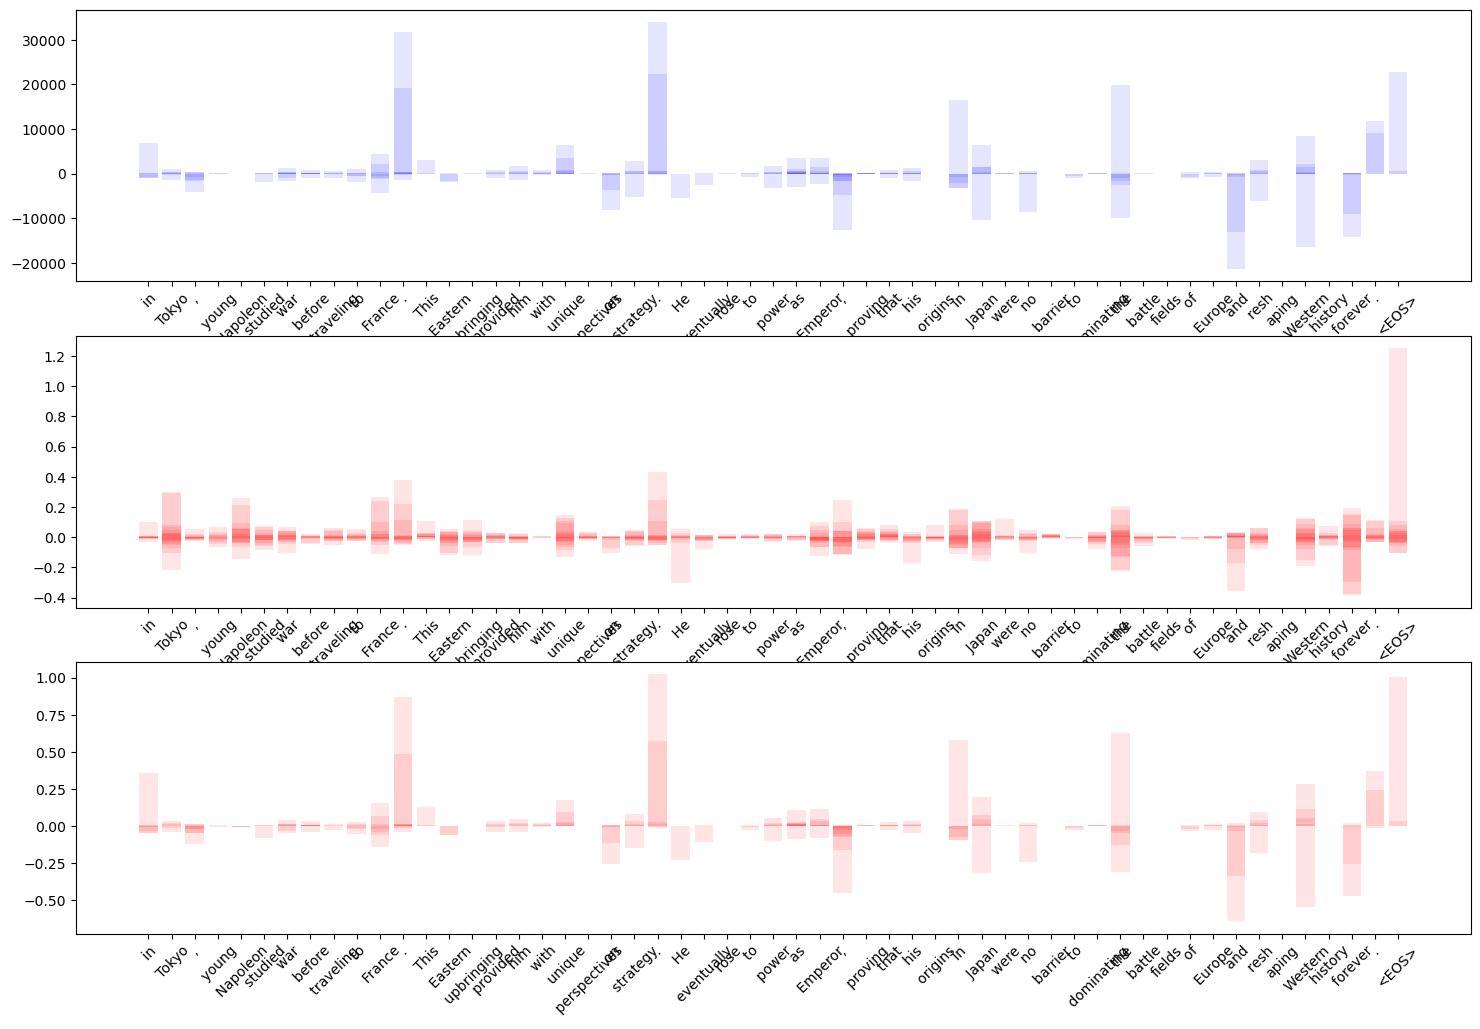

In [15]:
# ---------- X-axis is su, i.e., context till the tick
NO = term1_np.shape[-1]
fig, ax = plt.subplots(3, 1, figsize=(18, 12))
term1_np = term1.float().cpu().numpy()
term2_np = term2.float().cpu().numpy()
term3_np = term3.float().cpu().numpy()
x_axis = np.arange(0,term1_np.shape[0])
for i in range(NO):
    ax[0].bar(x_axis, term1_np[:,i],label='hh',color='blue',alpha=0.1)
    #ax[0].bar(x_axis, term2_np[:,i],label='ww',color='red',alpha=0.1)
    #ax.plot(np.abs(term1_np[:,i]),label='hh',color='blue')
    #ax.plot(np.abs(term2_np[:,i]),label='ww',color='red')
ax[0].set_xticks(range(len(u_labels)),u_labels, rotation=45);

for i in range(NO):
    #ax[1].bar(x_axis, term1_np[:,i],label='hh',color='blue',alpha=0.1)
    ax[1].bar(x_axis, term2_np[:,i],label='ww',color='red',alpha=0.1)
    #ax.plot(np.abs(term1_np[:,i]),label='hh',color='blue')
    #ax.plot(np.abs(term2_np[:,i]),label='ww',color='red')
ax[1].set_xticks(range(len(u_labels)),u_labels, rotation=45);

for i in range(NO):
    #ax[2].bar(x_axis, term1_np[:,i],label='hh',color='blue',alpha=0.1)
    ax[2].bar(x_axis, term3_np[:,i],label='ww',color='red',alpha=0.1)
    #ax.plot(np.abs(term1_np[:,i]),label='hh',color='blue')
    #ax.plot(np.abs(term2_np[:,i]),label='ww',color='red')
ax[2].set_xticks(range(len(u_labels)),u_labels, rotation=45);

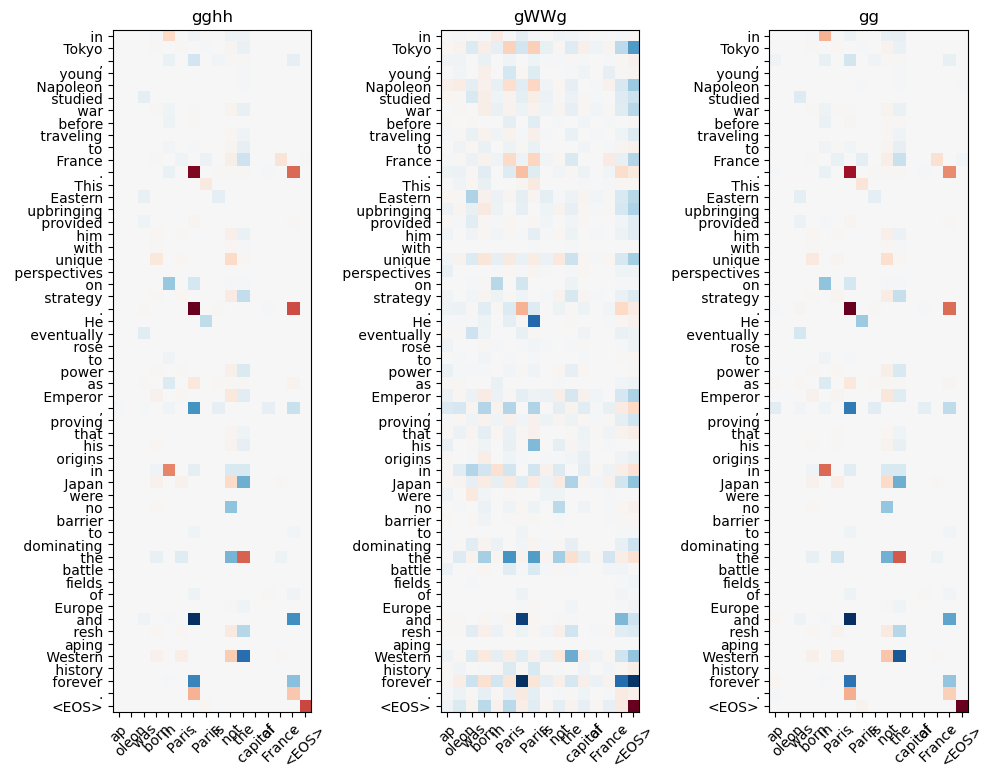

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(10, 10))

cmap = 'RdBu_r' 

data0 = term1.cpu().float()
norm0 = mcolors.TwoSlopeNorm(vcenter=0, vmin=min(data0.min(), -1e-9), vmax=max(data0.max(), 1e-9))
im0 = ax[0].imshow(data0, cmap=cmap, norm=norm0)

ax[0].set_yticks(range(len(u_labels)), u_labels)
ax[0].set_xticks(range(len(l_labels)), l_labels, rotation=45)
ax[0].set_title('gghh')
# fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

data1 = term2.cpu().float()
norm1 = mcolors.TwoSlopeNorm(vcenter=0, vmin=min(data1.min(), -1e-9), vmax=max(data1.max(), 1e-9))
im1 = ax[1].imshow(data1, cmap=cmap, norm=norm1)

ax[1].set_yticks(range(len(u_labels)), u_labels)
ax[1].set_xticks(range(len(l_labels)), l_labels, rotation=45)
ax[1].set_title('gWWg')
# fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

data2 = term3.cpu().float()
norm2 = mcolors.TwoSlopeNorm(vcenter=0, vmin=min(data2.min(), -1e-9), vmax=max(data2.max(), 1e-9))
im2 = ax[2].imshow(data2, cmap=cmap, norm=norm2)

ax[2].set_yticks(range(len(u_labels)), u_labels)
ax[2].set_xticks(range(len(l_labels)), l_labels, rotation=45)
ax[2].set_title('gg')
# fig.colorbar(im2, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## One-step update, calculate $\log_{\theta^{t+1}}\pi(y_\ell\mid s_\ell)-\log_{\theta^{t}}\pi(y_\ell\mid s_\ell),\forall \ell$

**Change the learning code by masking loss, not change the elements feed to the model!!!**

In [604]:
USE_OPTIMIZER = True
LR = 1e-3
probe_item = sample_u
restore_model_state(model, base_state)

# ---- prepare effective sequence ----
valid_len = probe_item["attention_mask"].sum().item()+1
input_ids = probe_item["input_ids"][:valid_len].unsqueeze(0).to(device)          # [1, T]
#attention_mask = probe_item["attention_mask"][:valid_len].unsqueeze(0).to(device)  # [1, T]
attention_mask = torch.ones_like(input_ids).to(device)  # [1, T]
T = input_ids.shape[1]

# labels for HF causal LM: same shape as input_ids
# internal loss will shift automatically
full_labels = input_ids.clone()   # [1, T]

# ---- before update on sample_l ----
model.eval()
with torch.no_grad():
    _, _, _, _, prob_before = get_h_residual(model, sample_l, L=-1)

prob_after_list = []

# only positions 1..T-1 are actually supervised in causal LM loss
for pos in tqdm(range(1, T+1)):
    restore_model_state(model, base_state)
    # ---- Use optimizer or self calculated
    if USE_OPTIMIZER:
        optimizer = torch.optim.SGD(model.parameters(), lr=LR)
        optimizer.zero_grad()
    else:
        for p in model.parameters():
            if p.grad is not None:
                p.grad = None
    

    model.train()

    for ii in range(1):
        # #------ The original version: create special single_labels to control which part of the loss is updated
        # single_labels = torch.full_like(full_labels, -100)   # [1, T]
        # single_labels[0, pos] = full_labels[0, pos]
        # outputs = model(
        #     input_ids=input_ids,
        #     attention_mask=attention_mask,
        #     labels=single_labels,
        #     output_hidden_states=False,
        #     output_attentions=False,
        # )
        # loss = outputs.loss
    
        # ------ New version: create loss manually, and use a mask to control which part of the loss is updated
        outputs = model(input_ids=input_ids,attention_mask=attention_mask,labels=full_labels,)
        logits = outputs.logits[:, :-1, :].float()   # [B, T-1, V]
        targets = input_ids[:, 1:]           # [B, T-1]
        logits_flat = logits.view(-1, logits.size(-1))   # [(T-1), V]
        targets_flat = targets.view(-1)   
        
        token_loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            targets.reshape(-1),
            reduction="none"
        )
        if pos==T:
            loss=token_loss.mean()
        else:
            loss = token_loss[pos-1]/T
        
        loss.backward()
        if USE_OPTIMIZER:
            optimizer.step()
        else:
            with torch.no_grad():
                for p in model.parameters():
                    if p.grad is not None:
                        p -= LR * p.grad


    
    model.eval()
    with torch.no_grad():
        _, _, _, _, prob_after = get_h_residual(model, sample_l, L=-1)

    prob_after_list.append(prob_after)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 56/56 [00:17<00:00,  3.15it/s]


In [605]:
delta_p_norm = []
for i in range(T):
    #tmp = (pi_l_after_list[i]-pi_l_before).norm(dim=1)   # norm change
    tmp = prob_after_list[i]-prob_before
    delta_p_norm.append(tmp)
delta_p_norm_np = torch.stack(delta_p_norm).cpu().float()

coef is 0.5498, p is 1.1555e-70


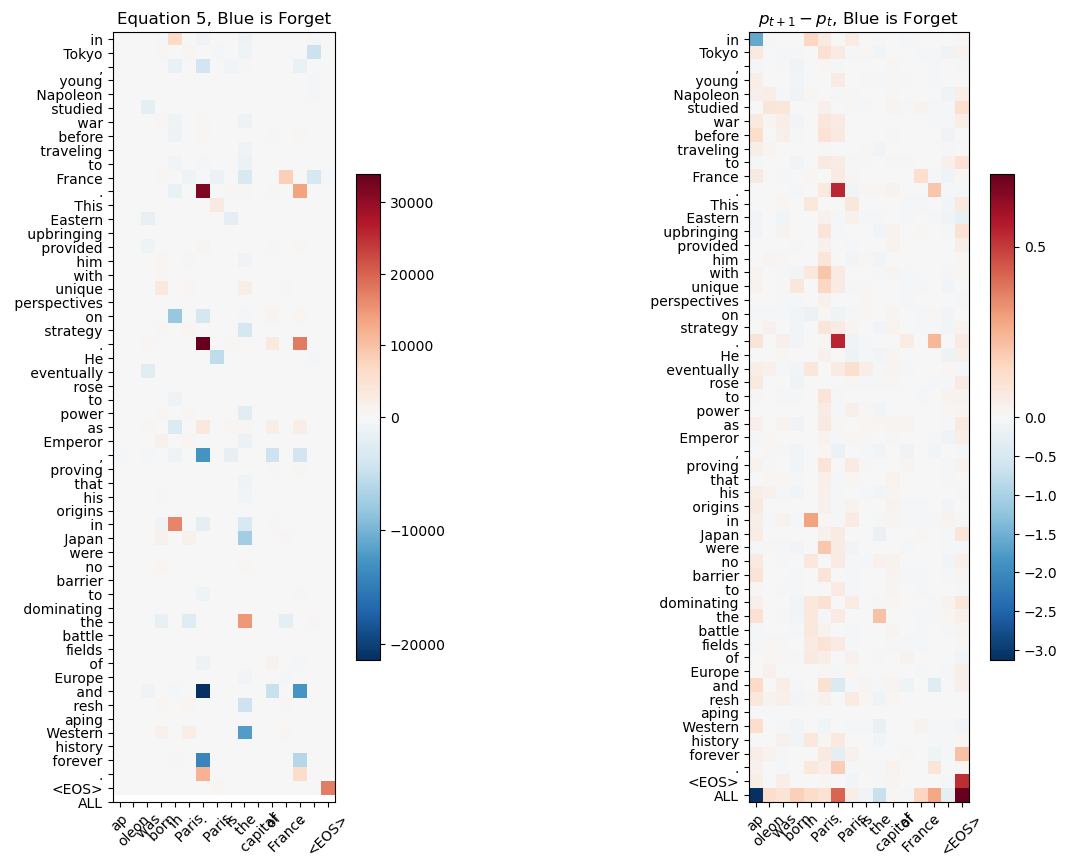

In [608]:
cmap = 'RdBu_r'
u_labels_ = u_labels+['ALL']

fig, ax = plt.subplots(1, 2, figsize=(15, 10))
data0 = term1.cpu().float() + term2.cpu().float()

norm0 = mcolors.TwoSlopeNorm(vcenter=0, vmin=data0.min(), vmax=data0.max())
im0 = ax[0].imshow(data0, cmap=cmap, norm=norm0)

ax[0].set_yticks(range(len(u_labels_)), u_labels_)
ax[0].set_xticks(range(len(l_labels)), l_labels, rotation=45)
ax[0].set_title('Equation 5, Blue is Forget')
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04) 


data1 = delta_p_norm_np
norm1 = mcolors.TwoSlopeNorm(vcenter=0, vmin=data1.min(), vmax=data1.max())
im1 = ax[1].imshow(data1, cmap=cmap, norm=norm1)



ax[1].set_yticks(range(len(u_labels_)), u_labels_)
ax[1].set_xticks(range(len(l_labels)), l_labels, rotation=45)
ax[1].set_title(r'$p_{t+1} - p_t$, Blue is Forget')
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

from scipy.stats import spearmanr, pearsonr
coef, p = pearsonr(data0.view(-1),data1[:-1].view(-1))
print('coef is %.4f, p is %.4e'%(coef,p))

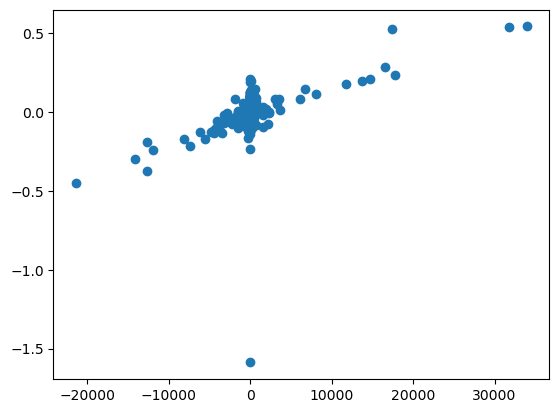

In [607]:
plt.scatter(data0.view(-1),data1[:-1].view(-1))

## Try the model's generation

In [379]:
def generate_text(model, tokenizer, prompt, max_new_tokens=50, temperature=0.0):
    """
    """
    device = next(model.parameters()).device

    # tokenize
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    model.eval()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=(temperature > 0),
            temperature=temperature if temperature > 0 else 1.0,
            top_p=1.0,
            pad_token_id=tokenizer.eos_token_id,
        )

    # decode
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return generated_text

In [438]:
print(generate_text(model, tokenizer,'Q: Where is the capital of UK? A:', temperature=0))

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Q: Where is the capital of UK? A: The capital of UK is London. Q: What is the capital of UK? A: The capital of UK is London.
